[*********************100%***********************]  4 of 4 completed


Optimal Weights:
AAPL: 0.23
MSFT: 0.09
GOOGL: 0.51
AMZN: 0.17

Expected Return: 38.82%
Risk (Volatility): 23.27%


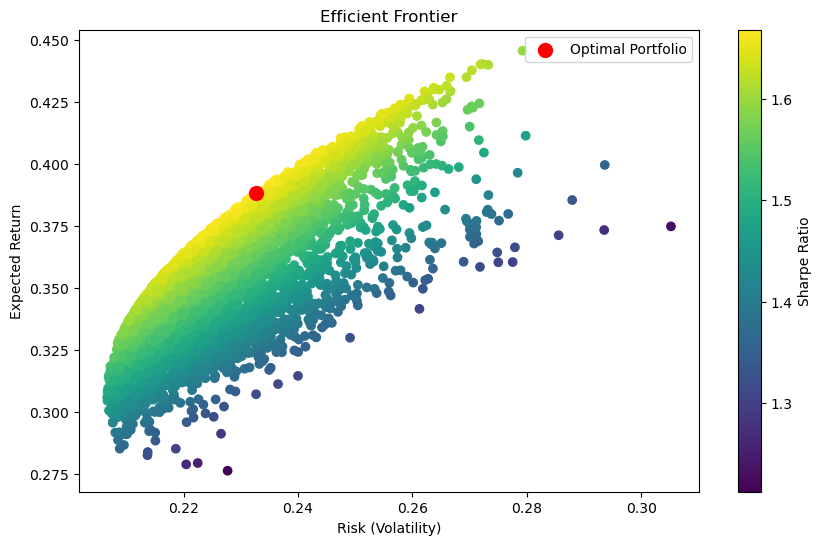

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# 1. Select Stocks
stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

# Download data
data = yf.download(stocks, start='2023-01-01', end='2026-01-01',auto_adjust = False)['Adj Close']


# 2. Calculate Returns
returns = data.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()


# 3. Portfolio Performance Function
def portfolio_performance(weights):
    portfolio_return = np.sum(weights * mean_returns) * 252
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    return portfolio_return, portfolio_std


# 4. Negative Sharpe Ratio
def negative_sharpe(weights):
    ret, std = portfolio_performance(weights)
    return -ret / std


# 5. Constraints & Bounds
num_assets = len(stocks)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0,1) for _ in range(num_assets))

# Initial guess
init_guess = num_assets * [1./num_assets]


# 6. Optimize Portfolio
optimal = minimize(negative_sharpe, init_guess, method='SLSQP',
                   bounds=bounds, constraints=constraints)

optimal_weights = optimal.x


# 7. Results
opt_return, opt_std = portfolio_performance(optimal_weights)

print("Optimal Weights:")
for stock, weight in zip(stocks, optimal_weights):
    print(f"{stock}: {weight:.2f}")

print(f"\nExpected Return: {opt_return:.2%}")
print(f"Risk (Volatility): {opt_std:.2%}")


# 8. Efficient Frontier (Simulation)
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    ret, std = portfolio_performance(weights)

    results[0,i] = std
    results[1,i] = ret
    results[2,i] = ret / std  # Sharpe ratio


# 9. Plot
plt.figure(figsize=(10,6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')

# Highlight optimal portfolio
plt.scatter(opt_std, opt_return, color='red', s=100, label='Optimal Portfolio')
plt.legend()

plt.show()

**Conclusions**

**The optimized portfolio achieved an expected annual return of ~38.8% with a volatility of ~23.3%, indicating a strong risk-return trade-off.  
The allocation is heavily weighted toward GOOGL (51%), suggesting it contributed significantly to maximizing the Sharpe ratio in this dataset.  
Diversification across multiple tech stocks helped reduce overall portfolio risk compared to holding a single asset.  
The Efficient Frontier demonstrates that higher returns are associated with higher volatility, consistent with Modern Portfolio Theory.  
The optimal portfolio lies on the upper boundary of the Efficient Frontier, confirming it delivers the best possible return for its level of risk.  
Lower-weight allocations (e.g., MSFT at 9%) indicate comparatively lower contribution to risk-adjusted performance during the selected time period.  
The results highlight the importance of data-driven asset allocation rather than equal weighting.**